## Initial Notes

- The positive class should be malignant=1. If benign=1, we would be measuring how well the model catches benign cases; it could potentially introduce false negatives (missing a cancer diagnosis).
- Given that the diagnosis ratio is 63% benign and 37% malignant, we will pass stratify=y for the train/test split.
- We will need the random_state argument so that every run does not produce a different split. Otherwise, we won't know if score change was do to either the split or parameter changes.
- Test size will be 0.3 because the dataset is small

In [29]:
import kagglehub
import os
import pandas as pd
import numpy as np

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Path to dataset files: /Users/mayihavecrumbofcoochieplz/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2


In [30]:
os.listdir('/Users/mayihavecrumbofcoochieplz/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2')

['data.csv']

In [36]:
df = pd.read_csv(path + '/data.csv')

In [40]:
# Getting columns, dropping empty column and id + diagnosis columns and encoding M=1, B=0
df = df.dropna(axis=1, how='all')
y = df['diagnosis'].map({'M': 1, 'B': 0})
df = df.drop(columns=['id', 'diagnosis'])

In [41]:
# Dropped column dataframe

df.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Train/Test Split

In [86]:
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.3, random_state=42, stratify=y)

## Baseline Model Notes

Model: Logistic Regression

- After training, each feature has one coefficient. Positive coefficient means feature increases predicted probability of malignancy. Larger magnitude means the feature matters a lot. It is very readable.
- Very fast (can update quickly)
- Decision Boundary: the baseline will show us how much complexity our model warrants

Scaling: 

- StandardScaler: works well when features are bell-shaped
- Regularization: applying penalty to keep coefficients small (L2 regularization)

Where to fit (data leakage): 

- Anything that learns from data should learn from training data only. The test set is a simulation of future, unseen data.
- Use sckit-learn Pipeline (handles fit-on-train automatically)

## Metric Notes

- Accuracy: Overall % correct. Misleading when classes are imbalanced.
- Recall (sensitivity): Of actual cancers, how many did we catch? Low recall means we did poor.
- Precision. Of the cases we called cancer, how many actually were? Low precision = lots of false alarms = unnecessary biopsies.
- F1 score: Harmonic mean of precision and recall. A single number that punishes you for being bad at either.
- ROC-AUC: Area under the ROC curve. Measures the model's ranking ability across all possible thresholds — independent of where you set the decision cutoff.
- Confusion matrix: A 2×2 table showing TP/FP/TN/FN. Always look at this — numbers lie, the matrix doesn't.

## Evaluation Notes

When we use the test performance to make a decision, our future choices are now influenced by the test set. For example, moving from logistical regression performance to random forest performance on test set. We are implicitly selecting the model that happens to do well on this particular test set, not the model that generalizes best.

Known as test set contamination.

Protocol: 

- Training Set: fitting, hyperparameter tuning, model comparison, etc.
- Test Set: Used only at the end for honest evaluation

Fit logistic regression to X_train and evaluate using cross validation on X_train.

In [90]:
# Creating pipeline and cross validate

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
results = cross_validate(pipe, X_train, y_train, cv=5, scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'])

# StandardScaler calls .fit(X_train): learning the mean and standard deviation of each feature from training data
# StandardScaler calls .transform(X_train): produces the scaled training data
# LogisticRegression calls .fit(scaled_X_train, y_train)

In [91]:
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    scores = results[f'test_{metric}']
    print(f'{metric}: {scores.mean():.4f} ± {scores.std():.4f}')

accuracy: 0.9723 ± 0.0218
precision: 0.9931 ± 0.0138
recall: 0.9317 ± 0.0578
f1: 0.9604 ± 0.0323
roc_auc: 0.9901 ± 0.0100


## Notes On Baseline

Better than majority-class baseline (63%). 7 out 100 cancer cases are missed. We would rather have a model that 
has more false positives as that's better than false negatives.

Next steps:

- Inspect coefficients
- Tune decision threshold

## Inspecting Coefficients

Here we can find the features that have the most impact on a cancer diagnosis.

In [97]:
pipe.fit(X_train, y_train)
lr = pipe.named_steps['logisticregression']

coefs = pd.Series(lr.coef_[0], index=X_train.columns)
order = coefs.abs().sort_values(ascending=False).index
coefs_sorted = coefs.loc[order]
print(coefs_sorted)

texture_worst              1.382380
radius_se                  1.204961
symmetry_worst             1.083643
area_se                    0.913672
compactness_se            -0.901709
area_worst                 0.882353
concave points_mean        0.848999
radius_worst               0.843263
concavity_worst            0.833666
concavity_mean             0.807619
perimeter_se               0.777558
perimeter_worst            0.712051
concave points_worst       0.678713
fractal_dimension_se      -0.507206
texture_mean               0.495005
smoothness_worst           0.469947
compactness_mean          -0.457695
area_mean                  0.410227
concave points_se          0.409768
texture_se                -0.397278
smoothness_mean            0.387175
symmetry_se               -0.327718
perimeter_mean             0.293132
radius_mean                0.289382
symmetry_mean             -0.238609
smoothness_se              0.219553
compactness_worst         -0.188113
fractal_dimension_mean    -0

## Decision Threshold Notes

No correct threshold. Context is important. Here, we want a higher recall because we want to reduce missed cancer diagnosis. It is better to have more false positives (lower precision) due to calling more things malignant. We will reduce the threshold from using by utilizing a target recall level (99% instead of the current 93%). We will compare how the other metrics change when optimizing for one metric. 

We will use cross-validation predictions on the training set.

In [111]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix
predictions = cross_val_predict(pipe, X_train, y_train, cv=5, method='predict_proba')
mal_predictions = predictions[:, 1]
mal_predictions

array([9.99999977e-01, 8.48586339e-01, 2.36513125e-03, 5.96349240e-04,
       2.77563011e-01, 9.99984440e-01, 1.15018669e-02, 7.24529015e-03,
       9.33275125e-01, 4.83010080e-02, 1.39407349e-04, 5.17035414e-03,
       1.27797089e-03, 5.55406607e-03, 1.88306735e-04, 2.34854226e-03,
       4.28157649e-01, 1.12315761e-01, 9.99701435e-01, 2.18647285e-02,
       2.21406930e-04, 9.99980932e-01, 9.33368627e-01, 1.90665693e-03,
       9.06721480e-01, 3.42021883e-04, 2.56004066e-04, 3.39082282e-02,
       7.16578599e-03, 9.83539754e-01, 9.99999798e-01, 9.97426243e-01,
       6.32979707e-05, 2.37425923e-03, 4.53161381e-04, 9.94138820e-01,
       9.16280651e-02, 3.67685148e-02, 8.43240624e-02, 3.14600228e-05,
       9.90680248e-01, 9.99999903e-01, 9.99943008e-01, 5.88095093e-04,
       3.33716015e-03, 9.98895169e-01, 9.99996719e-01, 4.22148413e-04,
       3.08447650e-02, 4.99395672e-05, 4.84110163e-05, 3.93478409e-04,
       9.99990455e-01, 6.46382477e-05, 1.00346546e-04, 9.99881966e-01,
      

In [116]:
# Testing different thresholds

thresholds = np.logspace(-4, 0, 200)
recalls = []
precisions = []

for t in thresholds: 
    preds = (mal_predictions >= t).astype(int)
    recalls.append(recall_score(y_train, preds))
    precisions.append(precision_score(y_train, preds))
    
recalls = np.array(recalls)
precisions = np.array(precisions)

f1s = []
for t in thresholds:
    preds = (mal_predictions >= t).astype(int)
    f1s.append(f1_score(y_train, preds))
f1s = np.array(f1s)

best_idx = f1s.argmax()
best_threshold = thresholds[best_idx]

In [117]:
for name, t in [('Default (0.5)', 0.5), (f'Tuned ({best_threshold:.3f})', best_threshold)]:
    preds = (mal_predictions >= t).astype(int)
    p = precision_score(y_train, preds)
    r = recall_score(y_train, preds)
    f = f1_score(y_train, preds)
    cm = confusion_matrix(y_train, preds)
    print(f'\n{name}')
    print(f'  precision: {p:.4f}')
    print(f'  recall:    {r:.4f}')
    print(f'  f1:        {f:.4f}')
    print(f'  confusion matrix:\n{cm}')


Default (0.5)
  precision: 0.9928
  recall:    0.9324
  f1:        0.9617
  confusion matrix:
[[249   1]
 [ 10 138]]

Tuned (0.396)
  precision: 0.9792
  recall:    0.9527
  f1:        0.9658
  confusion matrix:
[[247   3]
 [  7 141]]


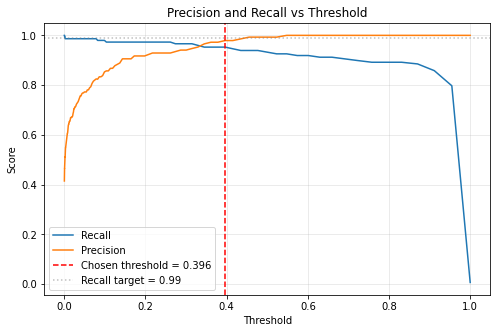

Best threshold (max F1): 0.3963
Best F1 score:           0.9658


In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(thresholds, recalls, label='Recall')
plt.plot(thresholds, precisions, label='Precision')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Chosen threshold = {best_threshold:.3f}')
plt.axhline(0.99, color='gray', linestyle=':', alpha=0.5, label='Recall target = 0.99')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f'Best threshold (max F1): {best_threshold:.4f}')
print(f'Best F1 score:           {f1s[best_idx]:.4f}')

## Final Notes

We did use an F1 score to tune the decision threshold, which does run counter to our original premise that false negatives are much worse than false positives (since F1 scores weigh recall and precision equally). However, we do want a balance.

We learned a couple things here (going chronologically). 

1. Drop unnecessary columns (id, diagnosis).

2. Use a baseline model (tells us a lot about what we're dealing with and if we need more complex models).

3. We needed to apply StandardScaler() due to such a difference in measurements between features. Otherwise, the regularization from LogisticRegression() would make the penalty scale unfair.

4. Never tune and compare models with the test set. Using the test set will only create a model that is particularly good for just that set. The test set should only be used at the end for a true measurement of our models. 

5. Testing different thresholds is a great way to improve the outcome of a model without changing it. We used cross_validation prediction to see how different thresholds changed recall vs precision and what the best middle ground is for both. 